In [14]:
# ============================================================
# 0. Imports
# ============================================================
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
from scipy.stats import spearmanr, pearsonr
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW

In [15]:
# ============================================================
# 1. Configuration
# ============================================================
NODES_CSV = "output/processed_fishtree_nodes.csv"
EDGE_INDEX_NPY = "output/processed_fishtree_edge_index.npy"
EDGE_WEIGHT_NPY = "output/processed_fishtree_edge_weight.npy"

DIST_MATRIX_PATH = "tree_distance_matrix_float32.npy"

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Model / optimization
EMB_DIM = 256                 # hyperbolic often needs fewer dims than Euclidean
LR = 1e-5
WEIGHT_DECAY = 0.0
NUM_STEPS = 200_000
BATCH_SIZE = 512 * 4

# Hyperbolic geometry
BALL_EPS = 1e-5
INIT_SCALE = 1e-3

# Loss
LAMBDA_PAIR = 1.0
TRIPLET_MARGIN = 0.0

# Scale tree distance before comparing to hyperbolic distance
# Start with this; tune later.
TREE_DISTANCE_SCALE = 1.0

# Distance binning / sampler
NUM_DISTANCE_BINS = 100
CLIP_DIST_PERCENTILE = 95.0

POS_LOCAL_ALPHA = 1.0
POS_UNIFORM_MIX = 0.10

NEG_OFFSET_ALPHA = 1.5
NEG_OFFSET_UNIFORM_MIX = 0.10

INCLUDE_OVERFLOW_AS_NEGATIVE = True
USE_WEIGHTED_TRIPLET_LOSS = False
USE_WEIGHTED_DISTANCE_LOSS = False

# Dense matrix construction
DIJKSTRA_BLOCK_SIZE = 256

# Evaluation
EVAL_NUM_PAIR_SAMPLES = 3000
EVAL_NUM_ANCHORS = 200
EVAL_CANDIDATE_SIZE = 2000

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Using device:", DEVICE)

Using device: cuda


In [16]:
# ============================================================
# 2. Load tree files
# ============================================================
nodes_df = pd.read_csv(NODES_CSV)
edge_index = np.load(EDGE_INDEX_NPY)
edge_weight = np.load(EDGE_WEIGHT_NPY)

num_nodes = len(nodes_df)

is_leaf = nodes_df["is_leaf"].astype(bool).to_numpy()
leaf_ids = np.where(is_leaf)[0]
internal_ids = np.where(~is_leaf)[0]

print("num_nodes:", num_nodes)
print("num leaves:", len(leaf_ids))
print("num internal:", len(internal_ids))

num_nodes: 22919
num leaves: 11460
num internal: 11459


In [17]:
# ============================================================
# 3. Build / load dense tree-distance matrix
# ============================================================
def build_sparse_graph(edge_index, edge_weight, num_nodes):
    src = edge_index[0].astype(np.int64)
    dst = edge_index[1].astype(np.int64)
    data = edge_weight.astype(np.float64)
    return csr_matrix((data, (src, dst)), shape=(num_nodes, num_nodes))


def build_distance_matrix_blockwise(graph, num_nodes, out_path, block_size=256):
    out_path = Path(out_path)

    dist_mem = np.lib.format.open_memmap(
        out_path,
        mode="w+",
        dtype=np.float32,
        shape=(num_nodes, num_nodes),
    )

    for start in tqdm(range(0, num_nodes, block_size), desc="Computing distance matrix"):
        end = min(start + block_size, num_nodes)
        indices = np.arange(start, end, dtype=np.int64)

        block = dijkstra(
            csgraph=graph,
            directed=False,
            indices=indices,
            return_predecessors=False,
        )

        dist_mem[start:end, :] = block.astype(np.float32)

    dist_mem.flush()
    del dist_mem


dist_matrix_path = Path(DIST_MATRIX_PATH)

if not dist_matrix_path.exists():
    graph = build_sparse_graph(edge_index, edge_weight, num_nodes)
    build_distance_matrix_blockwise(
        graph=graph,
        num_nodes=num_nodes,
        out_path=dist_matrix_path,
        block_size=DIJKSTRA_BLOCK_SIZE,
    )

D = np.load(dist_matrix_path)
print("D:", D.shape, D.dtype)
print("D memory GB:", D.nbytes / (1024 ** 3))

D: (22919, 22919) float32
D memory GB: 1.9568225778639317


In [18]:
# ============================================================
# 4. Estimate tau / clip distance
# ============================================================
def sample_distance_distribution_from_dense(D, num_samples=100_000):
    n = D.shape[0]
    dists = []

    while len(dists) < num_samples:
        u = random.randrange(n)
        v = random.randrange(n)
        if u != v:
            dists.append(float(D[u, v]))

    return np.array(dists, dtype=np.float32)


dist_samples = sample_distance_distribution_from_dense(D)
median_distance = float(np.median(dist_samples))
clip_distance = float(np.percentile(dist_samples, CLIP_DIST_PERCENTILE))

print("median distance:", median_distance)
print("clip_distance:", clip_distance)

for q in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"p{q:2d} = {np.percentile(dist_samples, q):.4f}")

median distance: 2.238694429397583
clip_distance: 3.5185067653656006
p 1 = 0.3572
p 5 = 0.7280
p10 = 0.9282
p25 = 1.3611
p50 = 2.2387
p75 = 3.0069
p90 = 3.3084
p95 = 3.5185
p99 = 4.0006


In [19]:
# ============================================================
# 5. Compact equal-width band index
# ============================================================
def build_compact_band_index_from_dense(D, clip_distance, num_regular_bins):
    n = D.shape[0]
    num_total_bins = num_regular_bins + 1

    sorted_ids = np.empty((n, n - 1), dtype=np.int32)
    bin_offsets = np.empty((n, num_total_bins + 1), dtype=np.int32)
    bin_edges = np.linspace(0.0, clip_distance, num_regular_bins + 1, dtype=np.float32)

    for u in tqdm(range(n), desc="Building compact band index"):
        row = D[u]

        order = np.argsort(row, kind="stable")
        order = order[order != u]

        sorted_ids[u, :] = order.astype(np.int32, copy=False)

        sorted_dists = row[order]
        ends = np.searchsorted(sorted_dists, bin_edges[1:], side="right").astype(np.int32)

        bin_offsets[u, 0] = 0
        bin_offsets[u, 1:num_regular_bins + 1] = ends
        bin_offsets[u, num_total_bins] = n - 1

    return {
        "sorted_ids": sorted_ids,
        "bin_offsets": bin_offsets,
        "bin_edges": bin_edges,
        "clip_distance": float(clip_distance),
        "num_regular_bins": int(num_regular_bins),
        "num_total_bins": int(num_total_bins),
    }


band_index = build_compact_band_index_from_dense(
    D=D,
    clip_distance=clip_distance,
    num_regular_bins=NUM_DISTANCE_BINS,
)

sorted_ids = band_index["sorted_ids"]
bin_offsets = band_index["bin_offsets"]

print("sorted_ids:", sorted_ids.shape, sorted_ids.dtype)
print("bin_offsets:", bin_offsets.shape, bin_offsets.dtype)

Building compact band index: 100%|██████████| 22919/22919 [00:20<00:00, 1138.66it/s]

sorted_ids: (22919, 22918) int32
bin_offsets: (22919, 102) int32


In [20]:
# ============================================================
# 6. Unified sampler
# ============================================================
def make_power_law_probs(num_items, alpha=1.0):
    x = np.arange(num_items, dtype=np.float64)
    probs = 1.0 / ((1.0 + x) ** alpha)
    probs /= probs.sum()
    return probs


def make_mixture_probs(num_items, local_alpha=1.5, uniform_mix=0.1):
    local = make_power_law_probs(num_items, alpha=local_alpha)
    uniform = np.ones(num_items, dtype=np.float64) / num_items
    probs = (1.0 - uniform_mix) * local + uniform_mix * uniform
    probs /= probs.sum()
    return probs


pos_bin_probs = make_mixture_probs(
    NUM_DISTANCE_BINS,
    local_alpha=POS_LOCAL_ALPHA,
    uniform_mix=POS_UNIFORM_MIX,
)

neg_offset_probs = make_mixture_probs(
    NUM_DISTANCE_BINS,
    local_alpha=NEG_OFFSET_ALPHA,
    uniform_mix=NEG_OFFSET_UNIFORM_MIX,
)

In [21]:
class UnifiedDistanceBinSampler:
    def __init__(
        self,
        D,
        sorted_ids,
        bin_offsets,
        num_regular_bins,
        include_overflow_as_negative=True,
        pos_bin_probs=None,
        neg_offset_probs=None,
        max_anchor_tries=100,
        max_bin_tries=100,
    ):
        self.D = D
        self.sorted_ids = sorted_ids
        self.bin_offsets = bin_offsets

        self.num_nodes = D.shape[0]
        self.num_regular_bins = num_regular_bins
        self.overflow_bin = num_regular_bins
        self.num_total_bins = num_regular_bins + 1

        self.include_overflow_as_negative = include_overflow_as_negative
        self.max_anchor_tries = max_anchor_tries
        self.max_bin_tries = max_bin_tries

        self.pos_bin_probs = np.asarray(pos_bin_probs, dtype=np.float64)
        self.pos_bin_probs /= self.pos_bin_probs.sum()

        self.neg_offset_probs = np.asarray(neg_offset_probs, dtype=np.float64)
        self.neg_offset_probs /= self.neg_offset_probs.sum()

    def _bin_slice(self, anchor, b):
        start = int(self.bin_offsets[anchor, b])
        end = int(self.bin_offsets[anchor, b + 1])
        return start, end

    def _bin_size(self, anchor, b):
        start, end = self._bin_slice(anchor, b)
        return end - start

    def _sample_pos_bin(self, anchor):
        for _ in range(self.max_bin_tries):
            b = int(np.random.choice(self.num_regular_bins, p=self.pos_bin_probs))
            if self._bin_size(anchor, b) > 0:
                return b
        return None

    def _sample_neg_bin(self, anchor, b_pos):
        max_regular_offset = self.num_regular_bins - 1 - b_pos

        for _ in range(self.max_bin_tries):
            offset = int(np.random.choice(len(self.neg_offset_probs), p=self.neg_offset_probs))

            if offset <= max_regular_offset:
                b_neg = b_pos + offset
            else:
                b_neg = self.overflow_bin if self.include_overflow_as_negative else self.num_regular_bins - 1

            if self._bin_size(anchor, b_neg) > 0:
                return b_neg

        return None

    def _sample_from_bin_uniform(self, anchor, b):
        start, end = self._bin_slice(anchor, b)
        if end <= start:
            return None

        pos = random.randrange(start, end)
        node = int(self.sorted_ids[anchor, pos])
        d = float(self.D[anchor, node])
        return node, d, pos

    def _sample_same_bin_ordered_pair(self, anchor, b):
        start, end = self._bin_slice(anchor, b)
        if end - start < 2:
            return None

        i = random.randrange(start, end - 1)
        j = random.randrange(i + 1, end)

        v = int(self.sorted_ids[anchor, i])
        w = int(self.sorted_ids[anchor, j])

        d_pos = float(self.D[anchor, v])
        d_neg = float(self.D[anchor, w])

        if d_pos < d_neg:
            return v, w, d_pos, d_neg
        if d_pos > d_neg:
            return w, v, d_neg, d_pos
        return None

    def sample_triplet(self):
        for _ in range(self.max_anchor_tries):
            anchor = random.randrange(self.num_nodes)

            b_pos = self._sample_pos_bin(anchor)
            if b_pos is None:
                continue

            b_neg = self._sample_neg_bin(anchor, b_pos)
            if b_neg is None:
                continue

            if b_neg == b_pos:
                pair = self._sample_same_bin_ordered_pair(anchor, b_pos)
                if pair is None:
                    continue
                v, w, d_pos, d_neg = pair
            else:
                pos = self._sample_from_bin_uniform(anchor, b_pos)
                neg = self._sample_from_bin_uniform(anchor, b_neg)
                if pos is None or neg is None:
                    continue

                v, d_pos, _ = pos
                w, d_neg, _ = neg

                if d_pos > d_neg:
                    v, w = w, v
                    d_pos, d_neg = d_neg, d_pos

                if d_pos == d_neg:
                    continue

            return {
                "anchor": anchor,
                "pos": v,
                "neg": w,
                "d_pos": d_pos,
                "d_neg": d_neg,
                "b_pos": b_pos,
                "b_neg": b_neg,
                "bin_offset": b_neg - b_pos if b_neg < self.overflow_bin else self.overflow_bin - b_pos,
            }

        return None

    def sample_batch(self, batch_size):
        batch = []
        while len(batch) < batch_size:
            t = self.sample_triplet()
            if t is not None:
                batch.append(t)
        return batch


sampler = UnifiedDistanceBinSampler(
    D=D,
    sorted_ids=sorted_ids,
    bin_offsets=bin_offsets,
    num_regular_bins=NUM_DISTANCE_BINS,
    include_overflow_as_negative=INCLUDE_OVERFLOW_AS_NEGATIVE,
    pos_bin_probs=pos_bin_probs,
    neg_offset_probs=neg_offset_probs,
)

In [22]:
# ============================================================
# 7. Hyperbolic geometry helpers
# ============================================================
def project_to_poincare_ball(x, eps=1e-5):
    """
    Projects points to the open unit ball.
    """
    norm = torch.norm(x, dim=-1, keepdim=True).clamp_min(eps)
    max_norm = 1.0 - eps
    scale = torch.clamp(max_norm / norm, max=1.0)
    return x * scale


def poincare_distance(x, y, eps=1e-5):
    """
    Pairwise row-wise Poincare distance.
    x, y: [B, D]
    returns: [B]
    """
    x = project_to_poincare_ball(x, eps)
    y = project_to_poincare_ball(y, eps)

    x2 = torch.sum(x * x, dim=-1)
    y2 = torch.sum(y * y, dim=-1)
    diff2 = torch.sum((x - y) ** 2, dim=-1)

    denom = (1.0 - x2) * (1.0 - y2)
    z = 1.0 + 2.0 * diff2 / torch.clamp(denom, min=eps)

    return torch.acosh(torch.clamp(z, min=1.0 + eps))


def poincare_pairwise_distance(x, y, eps=1e-5):
    """
    Full pairwise Poincare distance.
    x: [B, D]
    y: [N, D]
    returns: [B, N]
    """
    x = project_to_poincare_ball(x, eps)
    y = project_to_poincare_ball(y, eps)

    x2 = torch.sum(x * x, dim=-1, keepdim=True)      # [B, 1]
    y2 = torch.sum(y * y, dim=-1).unsqueeze(0)       # [1, N]
    diff2 = torch.cdist(x, y, p=2) ** 2              # [B, N]

    denom = (1.0 - x2) * (1.0 - y2)
    z = 1.0 + 2.0 * diff2 / torch.clamp(denom, min=eps)

    return torch.acosh(torch.clamp(z, min=1.0 + eps))

In [23]:
# ============================================================
# 8. Hyperbolic node embedding model
# ============================================================
class HyperbolicNodeEmbeddingModel(nn.Module):
    def __init__(self, num_nodes, emb_dim=64, init_scale=1e-3, eps=1e-5):
        super().__init__()
        self.embedding = nn.Embedding(num_nodes, emb_dim)
        self.eps = eps

        with torch.no_grad():
            self.embedding.weight.normal_(mean=0.0, std=init_scale)
            self.embedding.weight.copy_(project_to_poincare_ball(self.embedding.weight, eps=self.eps))

    def forward(self, node_ids):
        z = self.embedding(node_ids)
        return project_to_poincare_ball(z, eps=self.eps)

    def get_all_embeddings(self):
        return project_to_poincare_ball(self.embedding.weight, eps=self.eps)

    @torch.no_grad()
    def project_parameters(self):
        self.embedding.weight.copy_(project_to_poincare_ball(self.embedding.weight, eps=self.eps))

In [24]:
# ============================================================
# 9. Hyperbolic loss
# ============================================================
def hyperbolic_distance_weight(d, mode="none"):
    if mode == "none":
        return torch.ones_like(d)
    if mode == "sqrt":
        return 1.0 / torch.sqrt(1.0 + d)
    if mode == "inverse":
        return 1.0 / (1.0 + d)
    raise ValueError(mode)


def triplet_offset_weight(offsets, mode="none"):
    if mode == "none":
        return torch.ones_like(offsets)
    if mode == "soft":
        return 1.0 / torch.sqrt(1.0 + offsets)
    if mode == "offset_inv":
        return 0.5 + 1.5 / (1.0 + offsets)
    raise ValueError(mode)


def compute_hyperbolic_loss(
    model,
    batch_triplets,
    tree_distance_scale=1.0,
    lambda_pair=0.2,
    triplet_margin=0.0,
    device="cpu",
    eps=1e-5,
    use_weighted_triplet=False,
    weighted_triplet_mode="soft",
    use_weighted_distance=False,
    weighted_distance_mode="sqrt",
):
    u = torch.tensor([t["anchor"] for t in batch_triplets], dtype=torch.long, device=device)
    v = torch.tensor([t["pos"] for t in batch_triplets], dtype=torch.long, device=device)
    w = torch.tensor([t["neg"] for t in batch_triplets], dtype=torch.long, device=device)

    d_tree_uv = torch.tensor([t["d_pos"] for t in batch_triplets], dtype=torch.float32, device=device)
    d_tree_uw = torch.tensor([t["d_neg"] for t in batch_triplets], dtype=torch.float32, device=device)

    z_u = model(u)
    z_v = model(v)
    z_w = model(w)

    d_hyp_uv = poincare_distance(z_u, z_v, eps=eps)
    d_hyp_uw = poincare_distance(z_u, z_w, eps=eps)

    # Distance triplet loss: positive should be closer than negative.
    triplet_terms = F.relu(d_hyp_uv - d_hyp_uw + triplet_margin)

    if use_weighted_triplet:
        offsets = torch.tensor([t["bin_offset"] for t in batch_triplets], dtype=torch.float32, device=device)
        weights = triplet_offset_weight(offsets, mode=weighted_triplet_mode)
        triplet_loss = (weights * triplet_terms).mean()
    else:
        triplet_loss = triplet_terms.mean()

    target_uv = tree_distance_scale * d_tree_uv
    target_uw = tree_distance_scale * d_tree_uw

    if use_weighted_distance:
        weight_uv = hyperbolic_distance_weight(d_tree_uv, mode=weighted_distance_mode)
        weight_uw = hyperbolic_distance_weight(d_tree_uw, mode=weighted_distance_mode)
    else:
        weight_uv = torch.ones_like(d_tree_uv)
        weight_uw = torch.ones_like(d_tree_uw)

    pair_loss = (
        (weight_uv * (d_hyp_uv - target_uv) ** 2).mean()
        + (weight_uw * (d_hyp_uw - target_uw) ** 2).mean()
    )

    total_loss = triplet_loss + lambda_pair * pair_loss

    stats = {
        "loss": float(total_loss.item()),
        "triplet_loss": float(triplet_loss.item()),
        "pair_loss": float(pair_loss.item()),
        "mean_hyp_d_pos": float(d_hyp_uv.mean().item()),
        "mean_hyp_d_neg": float(d_hyp_uw.mean().item()),
        "mean_tree_d_pos": float(d_tree_uv.mean().item()),
        "mean_tree_d_neg": float(d_tree_uw.mean().item()),
        "mean_norm": float(torch.norm(model.get_all_embeddings(), dim=-1).mean().item()),
        "max_norm": float(torch.norm(model.get_all_embeddings(), dim=-1).max().item()),
    }

    return total_loss, stats

In [25]:
# ============================================================
# 10. Optional: choose a tree-distance scale
# ============================================================
# Hyperbolic distances can grow large near the boundary, but early training starts near zero.
# This scale controls how strongly raw tree distances are matched.
#
# Good starting options:
#   TREE_DISTANCE_SCALE = 1.0 / median_distance
#   TREE_DISTANCE_SCALE = 2.0 / median_distance
#   TREE_DISTANCE_SCALE = 5.0 / median_distance
#
# If embeddings rush to the boundary, lower this.
# If distances remain too small, raise it.

#TREE_DISTANCE_SCALE /= median_distance
print("TREE_DISTANCE_SCALE:", TREE_DISTANCE_SCALE)

TREE_DISTANCE_SCALE: 1.0


In [26]:
# ============================================================
# 11. Training
# ============================================================
model = HyperbolicNodeEmbeddingModel(
    num_nodes=num_nodes,
    emb_dim=EMB_DIM,
    init_scale=INIT_SCALE,
    eps=BALL_EPS,
).to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

history = []

for step in range(NUM_STEPS):
    batch = sampler.sample_batch(BATCH_SIZE)

    optimizer.zero_grad()

    loss, stats = compute_hyperbolic_loss(
        model=model,
        batch_triplets=batch,
        tree_distance_scale=TREE_DISTANCE_SCALE,
        lambda_pair=LAMBDA_PAIR,
        triplet_margin=TRIPLET_MARGIN,
        device=DEVICE,
        eps=BALL_EPS,
        use_weighted_triplet=USE_WEIGHTED_TRIPLET_LOSS,
        weighted_triplet_mode="soft",
        use_weighted_distance=USE_WEIGHTED_DISTANCE_LOSS,
        weighted_distance_mode="sqrt",
    )

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()
    model.project_parameters()

    history.append(stats)

    if step % 500 == 0:
        print(
            f"step={step:7d} "
            f"loss={stats['loss']:.4f} "
            f"triplet={stats['triplet_loss']:.4f} "
            f"pair={stats['pair_loss']:.4f} "
            f"hyp_pos={stats['mean_hyp_d_pos']:.3f} "
            f"hyp_neg={stats['mean_hyp_d_neg']:.3f} "
            f"mean_norm={stats['mean_norm']:.4f} "
            f"max_norm={stats['max_norm']:.4f}"
        )

step=      0 loss=4.2136 triplet=0.0009 pair=4.2127 hyp_pos=0.045 hyp_neg=0.045 mean_norm=0.0160 max_norm=0.0189
step=    500 loss=4.1164 triplet=0.0034 pair=4.1130 hyp_pos=0.094 hyp_neg=0.097 mean_norm=0.0320 max_norm=0.0789
step=   1000 loss=3.8962 triplet=0.0065 pair=3.8897 hyp_pos=0.144 hyp_neg=0.150 mean_norm=0.0480 max_norm=0.1463
step=   1500 loss=3.9738 triplet=0.0085 pair=3.9653 hyp_pos=0.195 hyp_neg=0.205 mean_norm=0.0637 max_norm=0.2133
step=   2000 loss=3.4825 triplet=0.0112 pair=3.4713 hyp_pos=0.239 hyp_neg=0.252 mean_norm=0.0790 max_norm=0.2793
step=   2500 loss=3.4654 triplet=0.0143 pair=3.4511 hyp_pos=0.291 hyp_neg=0.310 mean_norm=0.0938 max_norm=0.3424
step=   3000 loss=3.0534 triplet=0.0185 pair=3.0350 hyp_pos=0.335 hyp_neg=0.353 mean_norm=0.1082 max_norm=0.4069
step=   3500 loss=2.9231 triplet=0.0197 pair=2.9034 hyp_pos=0.375 hyp_neg=0.404 mean_norm=0.1220 max_norm=0.4703
step=   4000 loss=2.8656 triplet=0.0225 pair=2.8431 hyp_pos=0.426 hyp_neg=0.456 mean_norm=0.1353

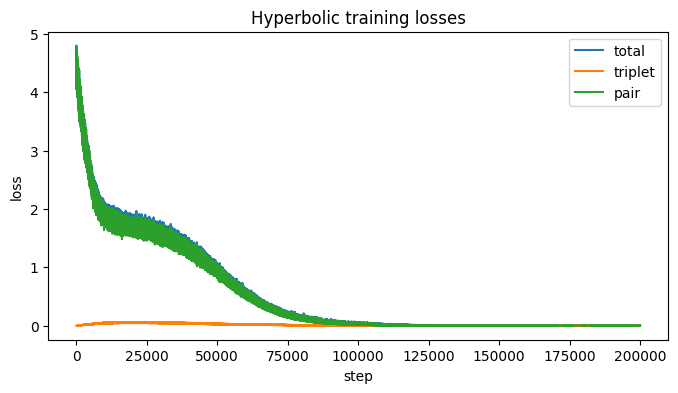

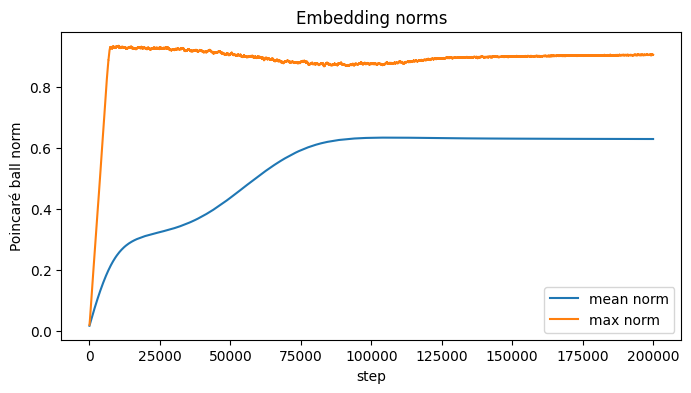

In [27]:
# ============================================================
# 12. Plot training curves
# ============================================================
losses = [x["loss"] for x in history]
triplet_losses = [x["triplet_loss"] for x in history]
pair_losses = [x["pair_loss"] for x in history]
mean_norms = [x["mean_norm"] for x in history]
max_norms = [x["max_norm"] for x in history]

plt.figure(figsize=(8, 4))
plt.plot(losses, label="total")
plt.plot(triplet_losses, label="triplet")
plt.plot(pair_losses, label="pair")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.title("Hyperbolic training losses")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(mean_norms, label="mean norm")
plt.plot(max_norms, label="max norm")
plt.xlabel("step")
plt.ylabel("Poincaré ball norm")
plt.legend()
plt.title("Embedding norms")
plt.show()

In [28]:
# ============================================================
# 13. Evaluation helpers
# ============================================================
@torch.no_grad()
def hyperbolic_distance_to_candidates(model, anchor, candidates, device="cpu", eps=1e-5):
    model.eval()

    nodes = torch.tensor([anchor] + list(candidates), dtype=torch.long, device=device)
    z = model(nodes)

    z_anchor = z[0:1]
    z_cands = z[1:]

    dists = poincare_pairwise_distance(z_anchor, z_cands, eps=eps)[0]
    return dists.cpu().numpy()


@torch.no_grad()
def evaluate_cutoff_correlation_hyperbolic(
    model,
    D,
    node_ids_a,
    node_ids_b,
    max_tree_dist,
    num_samples=3000,
    device="cpu",
    max_tries=200000,
    eps=1e-5,
):
    model.eval()

    tree_dists = []
    hyp_dists = []
    tries = 0

    node_ids_a = list(node_ids_a)
    node_ids_b = list(node_ids_b)

    while len(tree_dists) < num_samples and tries < max_tries:
        tries += 1

        u = int(random.choice(node_ids_a))
        v = int(random.choice(node_ids_b))
        if u == v:
            continue

        d_tree = float(D[u, v])
        if d_tree > max_tree_dist:
            continue

        z = model(torch.tensor([u, v], dtype=torch.long, device=device))
        d_hyp = float(poincare_distance(z[0:1], z[1:2], eps=eps).item())

        tree_dists.append(d_tree)
        hyp_dists.append(d_hyp)

    if len(tree_dists) < 10:
        return {"num_pairs": len(tree_dists), "spearman": np.nan, "pearson": np.nan}

    return {
        "num_pairs": len(tree_dists),
        "spearman": float(spearmanr(tree_dists, hyp_dists).correlation),
        "pearson": float(pearsonr(tree_dists, hyp_dists)[0]),
    }

In [29]:
@torch.no_grad()
def evaluate_triplet_accuracy_hyperbolic(model, sampler, num_triplets=5000, device="cpu", eps=1e-5):
    model.eval()

    records = []

    for _ in range(num_triplets):
        t = sampler.sample_triplet()
        if t is None:
            continue

        u, v, w = t["anchor"], t["pos"], t["neg"]

        z = model(torch.tensor([u, v, w], dtype=torch.long, device=device))
        d_uv = float(poincare_distance(z[0:1], z[1:2], eps=eps).item())
        d_uw = float(poincare_distance(z[0:1], z[2:3], eps=eps).item())

        records.append({
            "correct": float(d_uv < d_uw),
            "hyp_margin": d_uw - d_uv,
            "b_pos": t["b_pos"],
            "b_neg": t["b_neg"],
            "bin_offset": t["bin_offset"],
            "tree_d_pos": t["d_pos"],
            "tree_d_neg": t["d_neg"],
            "tree_d_gap": t["d_neg"] - t["d_pos"],
            "same_bin": int(t["b_pos"] == t["b_neg"]),
        })

    df = pd.DataFrame(records)

    return {
        "overall_accuracy": float(df["correct"].mean()),
        "same_bin_accuracy": float(df.loc[df["same_bin"] == 1, "correct"].mean()),
        "different_bin_accuracy": float(df.loc[df["same_bin"] == 0, "correct"].mean()),
        "mean_hyp_margin": float(df["hyp_margin"].mean()),
        "mean_tree_gap": float(df["tree_d_gap"].mean()),
        "num_triplets": int(len(df)),
    }, df

In [30]:
@torch.no_grad()
def evaluate_recall_at_k_hyperbolic(
    model,
    D,
    node_ids,
    k=10,
    num_anchors=200,
    candidate_size=2000,
    device="cpu",
    eps=1e-5,
):
    model.eval()

    recalls = []
    node_ids = list(node_ids)

    for _ in range(num_anchors):
        anchor = int(random.choice(node_ids))
        candidates = random.sample(node_ids, min(candidate_size, len(node_ids)))

        if anchor in candidates:
            candidates.remove(anchor)

        if len(candidates) < k:
            continue

        tree_dists = D[anchor, candidates]
        true_topk = set([candidates[i] for i in np.argsort(tree_dists)[:k]])

        hyp_dists = hyperbolic_distance_to_candidates(model, anchor, candidates, device=device, eps=eps)
        pred_topk = set([candidates[i] for i in np.argsort(hyp_dists)[:k]])

        recalls.append(len(true_topk & pred_topk) / k)

    return {
        "k": k,
        "num_anchors": len(recalls),
        "mean_recall": float(np.mean(recalls)),
        "std_recall": float(np.std(recalls)),
    }

In [31]:
@torch.no_grad()
def evaluate_anchor_local_ranking_spearman_hyperbolic(
    model,
    D,
    node_ids,
    neighborhood_size=50,
    num_anchors=200,
    candidate_pool_size=2000,
    device="cpu",
    eps=1e-5,
):
    model.eval()

    scores = []
    node_ids = list(node_ids)

    for _ in range(num_anchors):
        anchor = int(random.choice(node_ids))
        candidates = random.sample(node_ids, min(candidate_pool_size, len(node_ids)))

        if anchor in candidates:
            candidates.remove(anchor)

        if len(candidates) < neighborhood_size:
            continue

        tree_dists = D[anchor, candidates]
        nearest = [candidates[i] for i in np.argsort(tree_dists)[:neighborhood_size]]

        d_local = D[anchor, nearest]
        true_rank = np.argsort(np.argsort(d_local))

        hyp_dists = hyperbolic_distance_to_candidates(model, anchor, nearest, device=device, eps=eps)
        pred_rank = np.argsort(np.argsort(hyp_dists))

        rho = spearmanr(true_rank, pred_rank).correlation
        scores.append(float(rho))

    return {
        "num_anchors": len(scores),
        "mean_spearman": float(np.mean(scores)),
        "std_spearman": float(np.std(scores)),
    }

In [32]:
# ============================================================
# 14. Run focused evaluation
# ============================================================
for threshold in [0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]:
    res = evaluate_cutoff_correlation_hyperbolic(
        model=model,
        D=D,
        node_ids_a=leaf_ids,
        node_ids_b=leaf_ids,
        max_tree_dist=threshold,
        num_samples=EVAL_NUM_PAIR_SAMPLES,
        device=DEVICE,
        eps=BALL_EPS,
    )
    print(f"Cutoff {threshold}:", res)

triplet_summary, triplet_df = evaluate_triplet_accuracy_hyperbolic(
    model=model,
    sampler=sampler,
    num_triplets=5000,
    device=DEVICE,
    eps=BALL_EPS,
)
print("Triplet:", triplet_summary)

recall_10 = evaluate_recall_at_k_hyperbolic(
    model=model,
    D=D,
    node_ids=leaf_ids,
    k=10,
    num_anchors=EVAL_NUM_ANCHORS,
    candidate_size=EVAL_CANDIDATE_SIZE,
    device=DEVICE,
    eps=BALL_EPS,
)
print("Recall@10:", recall_10)

anchor_rank = evaluate_anchor_local_ranking_spearman_hyperbolic(
    model=model,
    D=D,
    node_ids=leaf_ids,
    neighborhood_size=50,
    num_anchors=EVAL_NUM_ANCHORS,
    candidate_pool_size=EVAL_CANDIDATE_SIZE,
    device=DEVICE,
    eps=BALL_EPS,
)
print("Anchor local ranking:", anchor_rank)

Cutoff 0.1: {'num_pairs': 131, 'spearman': 0.9401815253098853, 'pearson': 0.9588086040471537}
Cutoff 0.2: {'num_pairs': 466, 'spearman': 0.9742794912599118, 'pearson': 0.9832114494361359}
Cutoff 0.5: {'num_pairs': 2692, 'spearman': 0.9869582645276999, 'pearson': 0.9918231599435267}
Cutoff 1.0: {'num_pairs': 3000, 'spearman': 0.9917419694148568, 'pearson': 0.9960574379962766}
Cutoff 2.0: {'num_pairs': 3000, 'spearman': 0.9989284929918166, 'pearson': 0.9989028166287852}
Cutoff 5.0: {'num_pairs': 3000, 'spearman': 0.999757731639721, 'pearson': 0.999710444283119}
Cutoff 10.0: {'num_pairs': 3000, 'spearman': 0.9997532358614432, 'pearson': 0.9996517995791999}
Triplet: {'overall_accuracy': 0.886, 'same_bin_accuracy': 0.7229190421892816, 'different_bin_accuracy': 0.9741219963031423, 'mean_hyp_margin': 0.37187821225114165, 'mean_tree_gap': 0.37767664296340026, 'num_triplets': 5000}
Recall@10: {'k': 10, 'num_anchors': 200, 'mean_recall': 0.9155000000000001, 'std_recall': 0.09386026848459363}
Anc

Anchor-wise bin correlation: 100%|██████████| 200/200 [00:38<00:00,  5.19it/s]


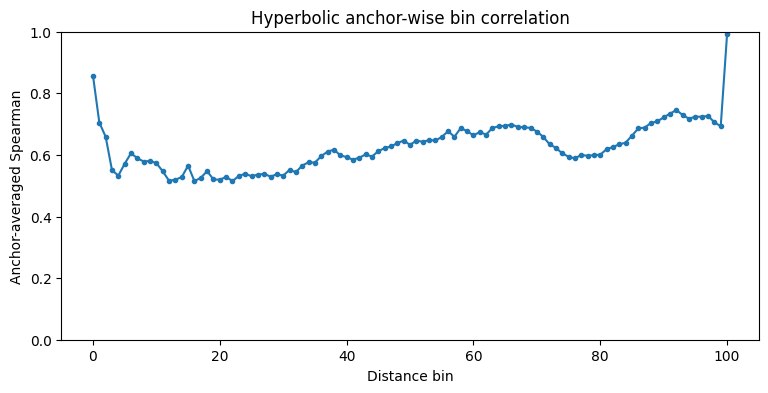

In [33]:
# ============================================================
# 15. Anchor-wise bin correlation for hyperbolic distances
# ============================================================
@torch.no_grad()
def evaluate_anchorwise_bin_correlation_hyperbolic(
    model,
    D,
    sorted_ids,
    bin_offsets,
    node_ids,
    num_anchors=200,
    samples_per_bin=100,
    device="cpu",
    min_pairs_per_bin=10,
    eps=1e-5,
):
    model.eval()

    node_ids = list(node_ids)
    num_bins = bin_offsets.shape[1] - 1
    anchors = random.sample(node_ids, min(num_anchors, len(node_ids)))

    records = []

    for anchor in tqdm(anchors, desc="Anchor-wise bin correlation"):
        anchor = int(anchor)

        for b in range(num_bins):
            start = int(bin_offsets[anchor, b])
            end = int(bin_offsets[anchor, b + 1])
            bin_nodes = sorted_ids[anchor, start:end]

            if len(bin_nodes) < min_pairs_per_bin:
                records.append({
                    "anchor": anchor,
                    "bin_index": b,
                    "num_pairs": len(bin_nodes),
                    "spearman": np.nan,
                    "pearson": np.nan,
                })
                continue

            if len(bin_nodes) > samples_per_bin:
                sampled_nodes = np.random.choice(bin_nodes, size=samples_per_bin, replace=False)
            else:
                sampled_nodes = bin_nodes

            sampled_nodes = sampled_nodes.astype(np.int64)

            tree_dists = D[anchor, sampled_nodes].astype(np.float64)
            hyp_dists = hyperbolic_distance_to_candidates(
                model,
                anchor,
                sampled_nodes.tolist(),
                device=device,
                eps=eps,
            )

            if len(np.unique(tree_dists)) < 2 or len(np.unique(hyp_dists)) < 2:
                spearman = np.nan
                pearson = np.nan
            else:
                spearman = spearmanr(tree_dists, hyp_dists).correlation
                pearson = pearsonr(tree_dists, hyp_dists)[0]

            records.append({
                "anchor": anchor,
                "bin_index": b,
                "num_pairs": len(sampled_nodes),
                "spearman": float(spearman) if not np.isnan(spearman) else np.nan,
                "pearson": float(pearson) if not np.isnan(pearson) else np.nan,
            })

    per_anchor_df = pd.DataFrame(records)

    summary_df = (
        per_anchor_df
        .groupby("bin_index")
        .agg(
            mean_spearman=("spearman", "mean"),
            std_spearman=("spearman", "std"),
            mean_pearson=("pearson", "mean"),
            std_pearson=("pearson", "std"),
            valid_anchors=("spearman", lambda x: int(x.notna().sum())),
            mean_num_pairs=("num_pairs", "mean"),
        )
        .reset_index()
    )

    return summary_df, per_anchor_df


anchor_bin_summary, anchor_bin_details = evaluate_anchorwise_bin_correlation_hyperbolic(
    model=model,
    D=D,
    sorted_ids=sorted_ids,
    bin_offsets=bin_offsets,
    node_ids=leaf_ids,
    num_anchors=200,
    samples_per_bin=100,
    device=DEVICE,
    eps=BALL_EPS,
)

plt.figure(figsize=(9, 4))
plt.plot(anchor_bin_summary["bin_index"], anchor_bin_summary["mean_spearman"], marker="o", markersize=3)
plt.xlabel("Distance bin")
plt.ylabel("Anchor-averaged Spearman")
plt.title("Hyperbolic anchor-wise bin correlation")
plt.ylim(0, 1.0)
plt.show()

In [34]:
# ============================================================
# 16. Save embeddings and model
# ============================================================
@torch.no_grad()
def export_hyperbolic_embeddings(model, nodes_df, out_csv="node_embeddings_hyperbolic.csv"):
    model.eval()
    Z = model.get_all_embeddings().cpu().numpy()

    emb_cols = [f"hyp_emb_{i}" for i in range(Z.shape[1])]
    emb_df = pd.DataFrame(Z, columns=emb_cols)

    out_df = pd.concat([nodes_df.reset_index(drop=True), emb_df], axis=1)
    out_df.to_csv(out_csv, index=False)
    return out_df


emb_df = export_hyperbolic_embeddings(model, nodes_df)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "num_nodes": num_nodes,
        "emb_dim": EMB_DIM,
        "tree_distance_scale": TREE_DISTANCE_SCALE,
        "ball_eps": BALL_EPS,
    },
    "node_embedding_model_hyperbolic.pt",
)

print("Saved hyperbolic embeddings and model.")

Saved hyperbolic embeddings and model.


In [38]:
# ============================================================
# Anchor-centered scatter for one distance bin
# ============================================================
@torch.no_grad()
def plot_anchor_centered_bin_scatter_hyperbolic(
    model,
    D,
    sorted_ids,
    bin_offsets,
    node_ids,
    bin_index,
    num_anchors=100,
    samples_per_anchor=50,
    device="cpu",
    eps=1e-5,
    alpha=0.35,
    point_size=10,
    min_points_per_anchor=10,
):
    model.eval()

    node_ids = list(node_ids)
    anchors = random.sample(node_ids, min(num_anchors, len(node_ids)))

    centered_tree_all = []
    centered_hyp_all = []
    per_anchor_records = []

    for anchor in tqdm(anchors, desc=f"Collecting centered bin {bin_index} points"):
        anchor = int(anchor)

        start = int(bin_offsets[anchor, bin_index])
        end = int(bin_offsets[anchor, bin_index + 1])
        bin_nodes = sorted_ids[anchor, start:end]

        if len(bin_nodes) < min_points_per_anchor:
            continue

        if len(bin_nodes) > samples_per_anchor:
            sampled_nodes = np.random.choice(bin_nodes, size=samples_per_anchor, replace=False)
        else:
            sampled_nodes = bin_nodes

        sampled_nodes = sampled_nodes.astype(np.int64)

        tree_dists = D[anchor, sampled_nodes].astype(np.float64)

        hyp_dists = hyperbolic_distance_to_candidates(
            model=model,
            anchor=anchor,
            candidates=sampled_nodes.tolist(),
            device=device,
            eps=eps,
        ).astype(np.float64)

        if len(np.unique(tree_dists)) < 2 or len(np.unique(hyp_dists)) < 2:
            continue

        tree_centered = tree_dists - tree_dists.mean()
        hyp_centered = hyp_dists - hyp_dists.mean()

        centered_tree_all.extend(tree_centered.tolist())
        centered_hyp_all.extend(hyp_centered.tolist())

        rho = spearmanr(tree_dists, hyp_dists).correlation
        r = pearsonr(tree_dists, hyp_dists)[0]

        per_anchor_records.append({
            "anchor": anchor,
            "num_points": len(sampled_nodes),
            "spearman": float(rho),
            "pearson": float(r),
            "tree_range": float(tree_dists.max() - tree_dists.min()),
            "hyp_range": float(hyp_dists.max() - hyp_dists.min()),
        })

    centered_tree_all = np.array(centered_tree_all)
    centered_hyp_all = np.array(centered_hyp_all)
    per_anchor_df = pd.DataFrame(per_anchor_records)

    if len(centered_tree_all) < 10:
        print(f"Not enough centered points for bin {bin_index}: {len(centered_tree_all)}")
        return None, per_anchor_df

    centered_spearman = spearmanr(centered_tree_all, centered_hyp_all).correlation
    centered_pearson = pearsonr(centered_tree_all, centered_hyp_all)[0]

    plt.figure(figsize=(6, 5))
    plt.scatter(
        centered_tree_all,
        centered_hyp_all,
        s=point_size,
        alpha=alpha,
    )
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.xlabel("Tree distance, centered within anchor")
    plt.ylabel("Hyperbolic distance, centered within anchor")
    plt.title(
        f"Anchor-centered bin {bin_index}\n"
        f"Spearman={centered_spearman:.3f}, Pearson={centered_pearson:.3f}, "
        f"anchors={len(per_anchor_df)}, n={len(centered_tree_all)}"
    )
    plt.show()

    return {
        "bin_index": bin_index,
        "num_points": int(len(centered_tree_all)),
        "num_anchors": int(len(per_anchor_df)),
        "centered_spearman": float(centered_spearman),
        "centered_pearson": float(centered_pearson),
        "centered_tree": centered_tree_all,
        "centered_hyp": centered_hyp_all,
    }, per_anchor_df

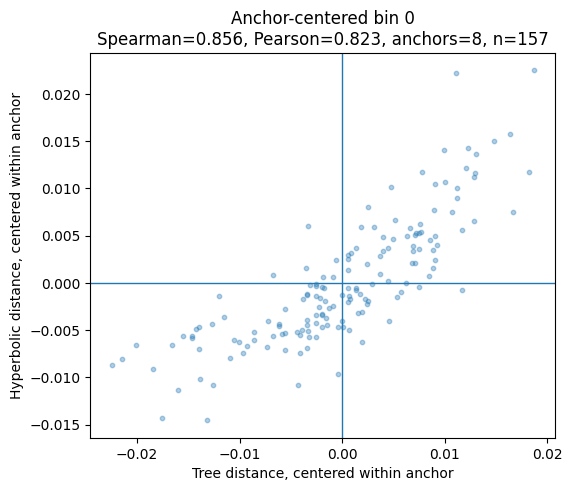

0 mean per-anchor Spearman: 0.8327766054435671 std: 0.05645808525542909


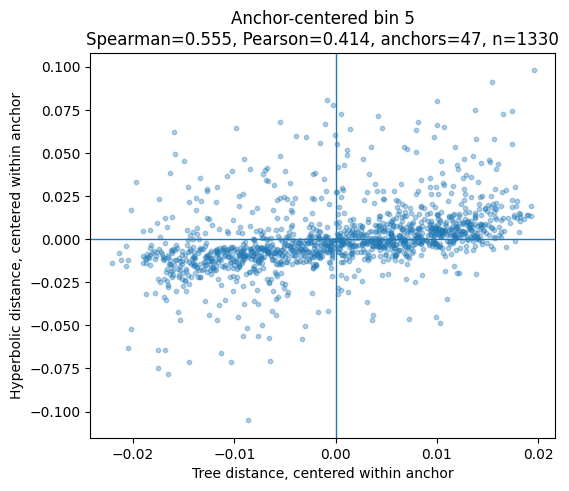

5 mean per-anchor Spearman: 0.5927682146253729 std: 0.1991988711438796


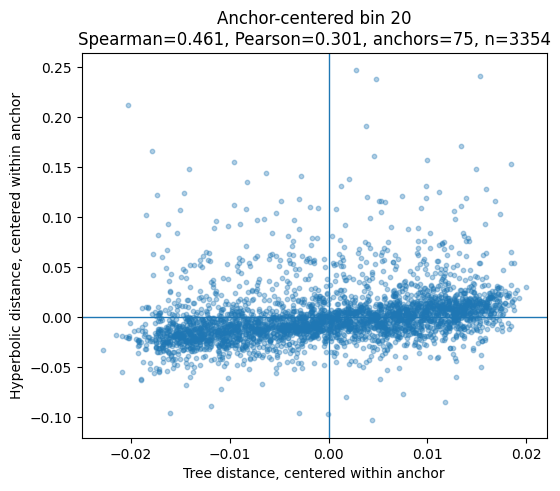

20 mean per-anchor Spearman: 0.5315984028385153 std: 0.2118717260235617


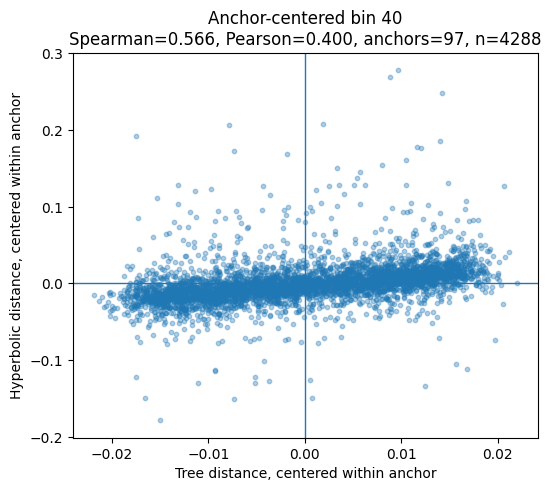

40 mean per-anchor Spearman: 0.623196394498534 std: 0.1778295862702776


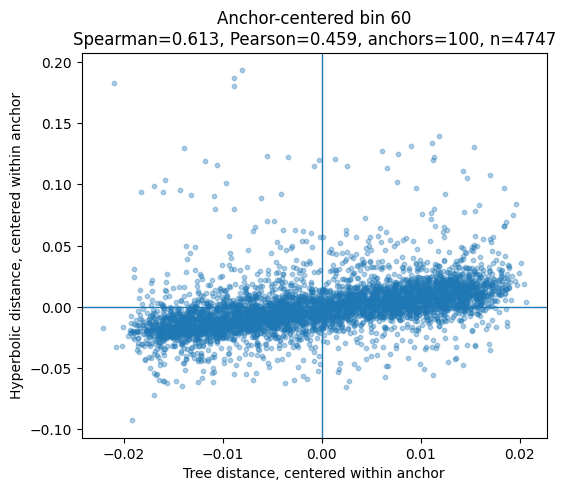

60 mean per-anchor Spearman: 0.6590518952442385 std: 0.1687064265272835


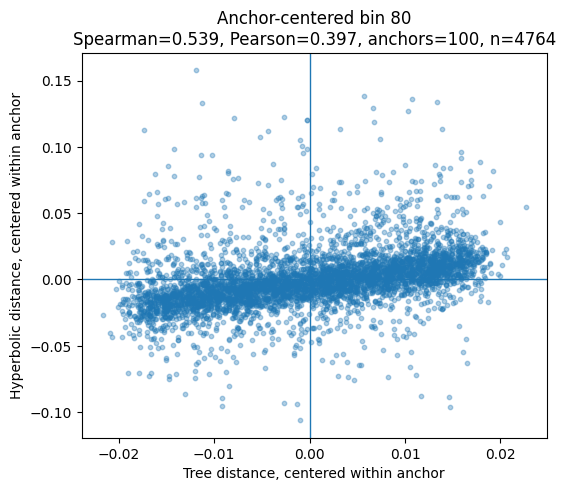

80 mean per-anchor Spearman: 0.5889567167840051 std: 0.18847089160605746


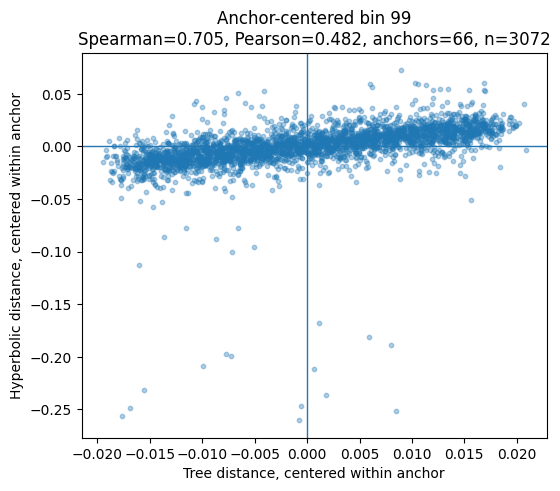

99 mean per-anchor Spearman: 0.7255528816729448 std: 0.13483040621160236


In [39]:
for b in [0, 5, 20, 40, 60, 80, 99]:
    centered_result, per_anchor_df = plot_anchor_centered_bin_scatter_hyperbolic(
        model=model,
        D=D,
        sorted_ids=sorted_ids,
        bin_offsets=bin_offsets,
        node_ids=leaf_ids,
        bin_index=b,
        num_anchors=100,
        samples_per_anchor=50,
        device=DEVICE,
        eps=BALL_EPS,
    )

    print(
        b,
        "mean per-anchor Spearman:",
        per_anchor_df["spearman"].mean(),
        "std:",
        per_anchor_df["spearman"].std(),
    )

In [43]:
import plotly.express as px

@torch.no_grad()
def plot_all_bins_uncentered_hyperbolic_plotly(
    model,
    D,
    sorted_ids,
    bin_offsets,
    node_ids,
    num_anchors=100,
    samples_per_bin_per_anchor=25,
    device="cpu",
    eps=1e-5,
    min_points_per_bin_anchor=5,
    max_bins=None,
):
    model.eval()

    node_ids = list(node_ids)
    anchors = random.sample(node_ids, min(num_anchors, len(node_ids)))

    num_bins = bin_offsets.shape[1] - 1
    if max_bins is not None:
        num_bins = min(num_bins, max_bins)

    records = []

    for anchor in tqdm(anchors, desc="Collecting uncentered all-bin points"):
        anchor = int(anchor)

        for b in range(num_bins):
            start = int(bin_offsets[anchor, b])
            end = int(bin_offsets[anchor, b + 1])
            bin_nodes = sorted_ids[anchor, start:end]

            if len(bin_nodes) < min_points_per_bin_anchor:
                continue

            if len(bin_nodes) > samples_per_bin_per_anchor:
                sampled_nodes = np.random.choice(
                    bin_nodes,
                    size=samples_per_bin_per_anchor,
                    replace=False,
                )
            else:
                sampled_nodes = bin_nodes

            sampled_nodes = sampled_nodes.astype(np.int64)

            tree_dists = D[anchor, sampled_nodes].astype(np.float64)

            hyp_dists = hyperbolic_distance_to_candidates(
                model=model,
                anchor=anchor,
                candidates=sampled_nodes.tolist(),
                device=device,
                eps=eps,
            ).astype(np.float64)

            for td, hd, node in zip(tree_dists, hyp_dists, sampled_nodes):
                records.append({
                    "anchor": anchor,
                    "node": int(node),
                    "bin_index": b,
                    "tree_distance": float(td),
                    "hyperbolic_distance": float(hd),
                })

    df = pd.DataFrame(records)

    rho = spearmanr(df["tree_distance"], df["hyperbolic_distance"]).correlation
    r = pearsonr(df["tree_distance"], df["hyperbolic_distance"])[0]

    fig = px.scatter(
        df,
        x="tree_distance",
        y="hyperbolic_distance",
        color="bin_index",
        color_continuous_scale="Viridis",
        opacity=0.45,
        hover_data={
            "anchor": True,
            "node": True,
            "bin_index": True,
            "tree_distance": ":.4f",
            "hyperbolic_distance": ":.4f",
        },
        title=(
            f"Tree distance vs hyperbolic distance across anchors/bins<br>"
            f"Spearman={rho:.3f}, Pearson={r:.3f}, n={len(df)}"
        ),
        labels={
            "tree_distance": "Tree distance",
            "hyperbolic_distance": "Hyperbolic distance",
            "bin_index": "Distance bin",
        },
    )

    fig.update_traces(marker=dict(size=5))
    fig.update_layout(width=950, height=650, template="plotly_white")
    fig.show()

    return df, fig

In [71]:
uncentered_df, uncentered_fig = plot_all_bins_uncentered_hyperbolic_plotly(
    model=model,
    D=D,
    sorted_ids=sorted_ids,
    bin_offsets=bin_offsets,
    node_ids=leaf_ids,
    num_anchors=1,
    samples_per_bin_per_anchor=25,
    device=DEVICE,
    eps=BALL_EPS,
)